# Python für mein Projekt

**Basics:**
- Variablen
- Schleifen
- Funktionen

**Geodaten & Raster:**
- rasterio (Raster lesen) --> manage, read & write rasters
- geopandas (Vektordaten)
- numpy (Berechnungen)

**Sentinel-Zugriff (API):**
- Daten holen über Copernicus Programme
- z. B. mit `sentinelsat`

**Analyse / Visualisierung:**
- matplotlib
- evtl. xarray (fortgeschritten)

## Libraries laden

In [1]:
# library rasterio laden
import rasterio
from rasterio import plot

# library matplotlib laden für Visualisierungen
import matplotlib.pyplot as plt

# library numpy für Berechnungen (wie NDVI)
import numpy as np # wenn ich die library abrufen will mache ich das mit np.

In [2]:
%matplotlib inline

In [3]:
# macht, dass es Plots direkt im Notebook anzeigt

## Bänder importieren

In [80]:
# alle Bänder in einem Ordner (hier 20m resolution) anzeigen

import os
os.listdir("S2C_MSIL2A_20250626T092051_N0511_R093_T35TLL_20250626T131216.SAFE/GRANULE/L2A_T35TLL_A004210_20250626T092359/IMG_DATA/R20m")

['T35TLL_20250626T092051_AOT_20m.jp2',
 'T35TLL_20250626T092051_B01_20m.jp2',
 'T35TLL_20250626T092051_B02_20m.jp2',
 'T35TLL_20250626T092051_B03_20m.jp2',
 'T35TLL_20250626T092051_B04_20m.jp2',
 'T35TLL_20250626T092051_B05_20m.jp2',
 'T35TLL_20250626T092051_B06_20m.jp2',
 'T35TLL_20250626T092051_B07_20m.jp2',
 'T35TLL_20250626T092051_B11_20m.jp2',
 'T35TLL_20250626T092051_B12_20m.jp2',
 'T35TLL_20250626T092051_B8A_20m.jp2',
 'T35TLL_20250626T092051_SCL_20m.jp2',
 'T35TLL_20250626T092051_TCI_20m.jp2',
 'T35TLL_20250626T092051_WVP_20m.jp2']

In [5]:
# Pfad im Ordner angeben, wo das Band abgelegt ist
red_path = "S2C_MSIL2A_20250626T092051_N0511_R093_T35TLL_20250626T131216.SAFE/GRANULE/L2A_T35TLL_A004210_20250626T092359/IMG_DATA/R10m/T35TLL_20250626T092051_B04_10m.jp2" 
nir_path = "S2C_MSIL2A_20250626T092051_N0511_R093_T35TLL_20250626T131216.SAFE/GRANULE/L2A_T35TLL_A004210_20250626T092359/IMG_DATA/R10m/T35TLL_20250626T092051_B08_10m.jp2" 

In [6]:
# Bänder einlesen
with rasterio.open(red_path) as band_red:
    red = band_red.read(1)

with rasterio.open(nir_path) as band_nir:
    nir = band_nir.read(1)

## Polygon importieren

In [7]:
# library laden
import geopandas as gpd
import fiona  # braucht es um Layer des GeoPackages anzuzeigen

In [8]:
# Pfad anzeigen
from pathlib import Path
Path.cwd()

WindowsPath('C:/Users/vikto/1 MeinJupyter/1 Master/PWRG2')

In [9]:
# Pfad zum GeoPackage
gpkg_path = "Data_Natura2000/Natura2000_end2024.gpkg"

In [10]:
# Alle Layer auflisten
layers = fiona.listlayers(gpkg_path)
print(layers)

['NaturaSite_polygon', 'BIOREGION', 'DESIGNATIONSTATUS', 'HABITATS', 'HABITATCLASS', 'NATURA2000SITES', 'OTHERSPECIES', 'METADATA', 'IMPACT', 'MANAGEMENT', 'SPECIES']


In [11]:
# Layer auswählen
aoi = gpd.read_file(gpkg_path, layer="NaturaSite_polygon")

In [12]:
# AOI plotten
# aoi.plot()

In [13]:
# Anschauen, welche Informationen sich in aoi befinden
print(aoi)

        SITECODE                  SITENAME  MS SITETYPE INSPIRE_ID  \
0      SE0320228                  Lunnarna  SE        C              
1      SE0340103               Kallgatburg  SE        B              
2      SE0430147  Jonstorp-Vegeåns mynning  SE        B              
3      SE0820084                  Åträsket  SE        B              
4      SE0110366                        Ön  SE        B              
...          ...                       ...  ..      ...        ...   
27168  SE0340125                  Högklint  SE        B              
27169  SE0720321               Bötelsmyren  SE        B              
27170  SE0710060                 Prästflon  SE        B              
27171  SE0410122                 Grimsmåla  SE        B              
27172  SE0230249              Kushults äng  SE        B              

                                                geometry  
0      POLYGON ((4524927.242 3742218.657, 4525316.92 ...  
1      POLYGON ((4837612.182 3874303.987,

In [14]:
# Nach Gebiet filtern
aoi_fagaras = aoi[aoi['SITECODE'] == 'ROSAC0122'] # Info aus der Map aus
# https://natura2000.eea.europa.eu/?views=Blank_View#data_s=id%3AdataSource_7-Layman_sites_2246%3A21420
#### meine AOI: Munții Făgăraș (Făgăraș-Gebirge) ####

In [15]:
print(aoi_fagaras)

        SITECODE        SITENAME  MS SITETYPE INSPIRE_ID  \
12291  ROSAC0122  Munții Făgăraș  RO        B              

                                                geometry  
12291  POLYGON ((5453305.736 2580764.134, 5453320.951...  


<Axes: >

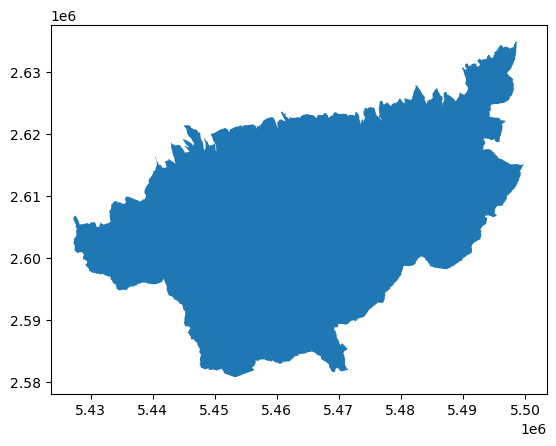

In [16]:
# AOI plotten
aoi_fagaras.plot()

## Koordinatensystem prüfen
wenn ich den Raster auf das Polygon zuschneiden will, müssen beide im gleichen Koordinatensystem vorliegen!!

In [17]:
print(aoi_fagaras.crs)
print(band_nir.crs)
print(band_red.crs)

EPSG:3035
EPSG:32635
EPSG:32635


### Koordinatensystem ändern

In [18]:
# Koordinatensystem an jenes der Sentinel-2 Daten anpassen (EPSG 32635 = UTM Zone 35N)
aoi_fagaras = aoi_fagaras.to_crs(band_nir.crs)
print(aoi_fagaras.crs)

PROJCS["WGS 84 / UTM zone 35N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",27],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32635"]]


## Raster auf Polygon clippen

In [19]:
# libraries laden
from rasterio.mask import mask 
import rasterio
import fiona

In [20]:
# NIR-Band zuschneiden
with rasterio.open(nir_path) as src:
    nir_clip, nir_transform = mask(src, aoi_fagaras.geometry, crop=True)

# RED-Band zuschneiden
with rasterio.open(red_path) as src:
    red_clip, red_transform = mask(src, aoi_fagaras.geometry, crop=True)

In [65]:
# Arrays auf 2D reduzieren
# ohne das Reduzieren auf 3D ist der Array: (Bänder, Höhe, Breite)
# wenn ich nur 1 Band habe brauche ich diese Information nicht --> 2D: (Höhe, Breite)
# mit [0] wähle ich das 1. Band aus; mit [2] würde ich das 3. Band auswählen etc.
nir_clip = nir_clip[0]
red_clip = red_clip[0]

### Plotten

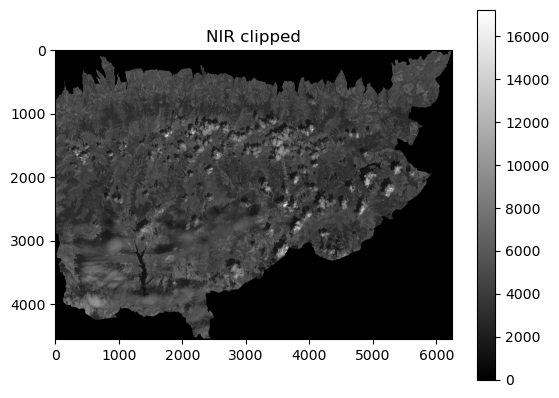

In [31]:
import matplotlib.pyplot as plt

plt.imshow(nir_clip, cmap="gray")
plt.title("NIR clipped")
plt.colorbar()

# optinal: Plot als PNG speichern --> vor plt.show()!!!
plt.savefig("nir_clipped.png", dpi=300, bbox_inches="tight")

# dann anzeigen
plt.show()

## NDVI berechnen und Plotten

In [40]:
ndvi = (nir_clip - red_clip)/(nir_clip + red_clip)

C:\Users\vikto\AppData\Local\Temp\ipykernel_26828\1503858868.py:1: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir_clip - red_clip)/(nir_clip + red_clip)


In [24]:
# die Warnmeldung kommt von 0-Werten in den Daten (Python versucht durch 0 zu teilen, was eine Fehlermeldung auslöst)

In [35]:
# liegt ndvi in 2D oder 3D vor? --> Shape anschauen
print(ndvi.shape) # --> 2D

(4550, 6245)


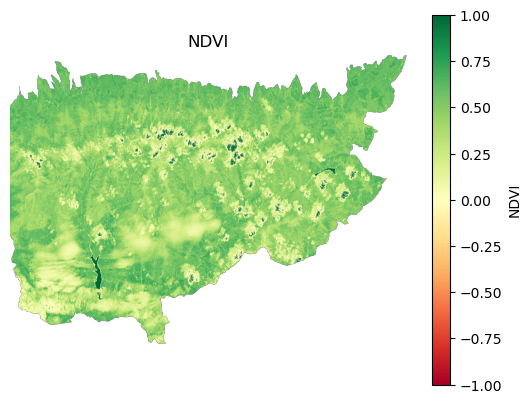

In [39]:
import matplotlib.pyplot as plt

plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1) # cmap = Farbskala, vmin/vmax = Wertebereich
plt.colorbar(label="NDVI") # Legendentitel
plt.title("NDVI") # Plottitel
plt.axis("off") # Achsen (Koordinaten) ausblenden

plt.savefig("ndvi.png", dpi=300, bbox_inches="tight") # Plot direkt als PNG speichern

plt.show()

### Kontrast verbessern

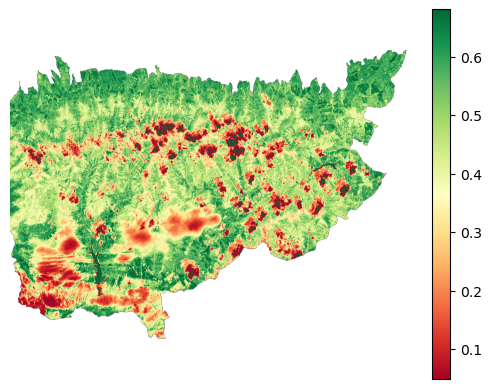

In [43]:
import numpy as np

plt.imshow(
    ndvi,                                    # Raster (Array), deer geplottet werden soll
    cmap="RdYlGn",                           # Farbskala
    vmin=np.nanpercentile(ndvi, 2),          # setzt unteren Farbwert: der Wert, unter dem (hier) 2% der Daten liegen
    vmax=np.nanpercentile(ndvi, 98)          # setzt oberen Farbwert: der Wert, unter dem (hier) 98% der Daten liegen
)
plt.colorbar()                               # Farbskala (Legende) rechts anzeigen
plt.axis("off")                              # Achsenbeschriftung (Koordinaten) entfernen
plt.show()

## Wolkenmaskierung: SCL von Sentinel (im Ordner 20m) einfügen

Infos zum SCL: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/scene-classification/

- 0	No data
- 1	Defective
- 2	Schatten
- 3	Cloud shadows
- 4	Vegetation
- 5	Bare soil
- 6	Wasser
- 7	Unclassified
- 8	Wolken (mittel)
- 9	Wolken (hoch)
- 10 Cirrus
- 11 Schnee

In [66]:
# Pfad im Ordner angeben, wo das Band abgelegt ist
scl_path = "S2C_MSIL2A_20250626T092051_N0511_R093_T35TLL_20250626T131216.SAFE/GRANULE/L2A_T35TLL_A004210_20250626T092359/IMG_DATA/R20m/T35TLL_20250626T092051_SCL_20m.jp2" 

In [67]:
# Band SCL einlesen
with rasterio.open(scl_path) as band_scl:
    scl = band_scl.read(1)

In [68]:
# gleiches Koordinatensystem?
print(band_scl.crs)
print(band_red.crs)

EPSG:32635
EPSG:32635


In [69]:
# SCL-Layer zuschneiden
with rasterio.open(scl_path) as src:
    scl_clip, scl_transform = mask(src, aoi_fagaras.geometry, crop=True)

# auf 2D reduzieren
scl_clip = scl_clip[0]

In [70]:
# Kontrolle --> Shape anschauen
print(scl_clip.shape) # --> 2D

(2275, 3123)


### SCL-Raster resampeln auf 10m (SCL = 20m Auflösung)

In [71]:
from rasterio.enums import Resampling

with rasterio.open(scl_path) as src:
    scl = src.read(
        1,
        out_shape=(
            src.height * 2,  # Faktor 2: 20m → 10m
            src.width * 2
        ),
        resampling=rasterio.enums.Resampling.nearest
    )

### Cloud-Maske erstellen

In [72]:
cloud_mask = (scl_clip == 8) | (scl_clip == 9) | (scl_clip == 10)

### NDVI bereinigen

In [73]:
import numpy as np

ndvi_clean = np.where(cloud_mask, np.nan, ndvi)

ValueError: operands could not be broadcast together with shapes (2275,3123) () (4550,6245) 

C:\Users\vikto\AppData\Local\Temp\ipykernel_26828\549698884.py:30: RuntimeWarning: invalid value encountered in divide
  ndvi = (nir_clip.astype(float) - red_clip.astype(float)) / (nir_clip + red_clip)


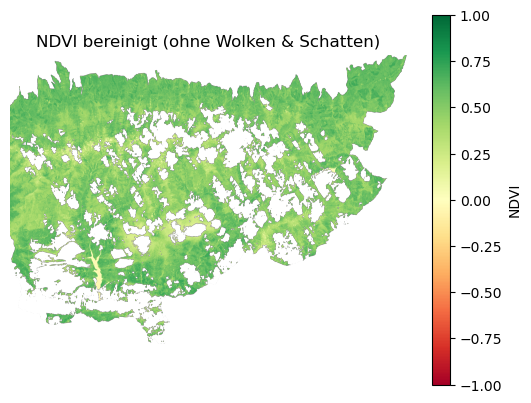

In [75]:
import rasterio
from rasterio.mask import mask
import rasterio.warp
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Pfade
red_path = "S2C_MSIL2A_20250626T092051_N0511_R093_T35TLL_20250626T131216.SAFE/GRANULE/L2A_T35TLL_A004210_20250626T092359/IMG_DATA/R10m/T35TLL_20250626T092051_B04_10m.jp2" 
nir_path = "S2C_MSIL2A_20250626T092051_N0511_R093_T35TLL_20250626T131216.SAFE/GRANULE/L2A_T35TLL_A004210_20250626T092359/IMG_DATA/R10m/T35TLL_20250626T092051_B08_10m.jp2" 
scl_path = "S2C_MSIL2A_20250626T092051_N0511_R093_T35TLL_20250626T131216.SAFE/GRANULE/L2A_T35TLL_A004210_20250626T092359/IMG_DATA/R20m/T35TLL_20250626T092051_SCL_20m.jp2" 

# AOI: geopandas GeoDataFrame
# aoi_fagaras.geometry

# -------------------------
# 1️⃣ NIR + RED zuschneiden
with rasterio.open(nir_path) as src:
    nir_clip, nir_transform = mask(src, aoi_fagaras.geometry, crop=True)
    nir_clip = nir_clip[0]
    ndvi_crs = src.crs
    ndvi_transform = nir_transform

with rasterio.open(red_path) as src:
    red_clip, _ = mask(src, aoi_fagaras.geometry, crop=True)
    red_clip = red_clip[0]

# -------------------------
# 2️⃣ NDVI berechnen
ndvi = (nir_clip.astype(float) - red_clip.astype(float)) / (nir_clip + red_clip)

# -------------------------
# 3️⃣ SCL zuschneiden
with rasterio.open(scl_path) as src:
    scl_clip, scl_clip_transform = mask(src, aoi_fagaras.geometry, crop=True)
    scl_clip = scl_clip[0]  # 2D
    scl_crs = src.crs

# -------------------------
# 4️⃣ SCL auf NDVI-Auflösung resamplen
scl_resampled = np.empty_like(ndvi, dtype=scl_clip.dtype)

rasterio.warp.reproject(
    source=scl_clip,
    destination=scl_resampled,
    src_transform=scl_clip_transform,
    dst_transform=ndvi_transform,
    src_crs=scl_crs,
    dst_crs=ndvi_crs,
    resampling=rasterio.enums.Resampling.nearest
)

# -------------------------
# 5️⃣ Cloud-Maske erstellen (Wolken + Cirrus)
cloud_mask = (scl_resampled == 3) | (scl_resampled == 8) | (scl_resampled == 9) | (scl_resampled == 10)

# -------------------------
# 6️⃣ NDVI bereinigen
ndvi_clean = np.where(cloud_mask, np.nan, ndvi)

# -------------------------
# 7️⃣ Plot (optional)
plt.imshow(ndvi_clean, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("NDVI bereinigt (ohne Wolken & Schatten)")
plt.axis("off")
plt.show()

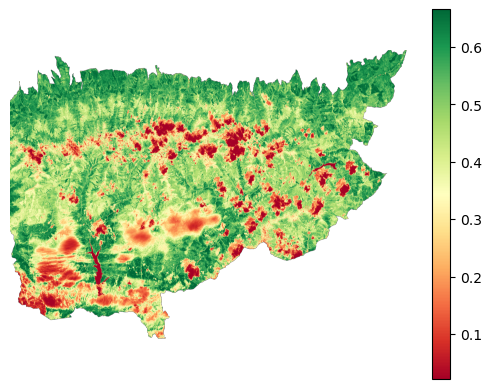

In [76]:
import numpy as np

plt.imshow(
    ndvi,                                    # Raster (Array), deer geplottet werden soll
    cmap="RdYlGn",                           # Farbskala
    vmin=np.nanpercentile(ndvi, 2),          # setzt unteren Farbwert: der Wert, unter dem (hier) 2% der Daten liegen
    vmax=np.nanpercentile(ndvi, 98)          # setzt oberen Farbwert: der Wert, unter dem (hier) 98% der Daten liegen
)
plt.colorbar()                               # Farbskala (Legende) rechts anzeigen
plt.axis("off")                              # Achsenbeschriftung (Koordinaten) entfernen
plt.show()

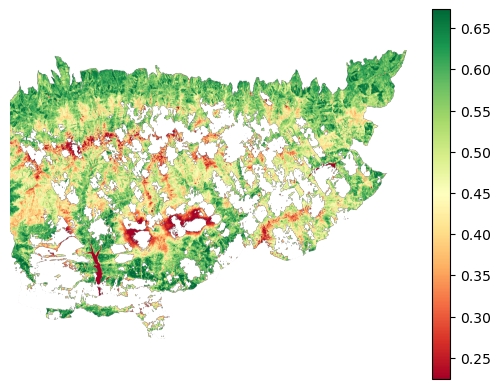

In [81]:
import numpy as np

plt.imshow(
    ndvi_clean,                               
    cmap="RdYlGn",                         
    vmin=np.nanpercentile(ndvi_clean, 2),        
    vmax=np.nanpercentile(ndvi_clean, 98)      
)
plt.colorbar()                              
plt.axis("off") 
plt.savefig("ndvi_clean.png", dpi=900, bbox_inches="tight") # Plot direkt als PNG speichern
plt.show()

In [82]:
import pandas as pd

In [ ]:
pd.DataFrame